# Self-study try-it activity 13.1: Changing the parameters of a logistic function

## Introduction

In this notebook, you'll analyse logistic regression using the [Pima Indians diabetes data set](https://www.kaggle.com/uciml/pima-indians-diabetes-database). The goal is to predict the onset of diabetes based on various diagnostic measurements.

Start by downloading and importing the data set.

Then, review a brief recap of logistic regression and its training procedure. You’ll fit a logistic regression model to the data set.

Next, you'll explore how to choose the best model for classification. This includes a short introduction to regularisation. The second set of exercises focuses on selecting the best regularisation constant and examining its effect on the model.

In [1]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

### Download and preprocess the data

- Download the `diabetes.csv` data set and store it in the variable `data`. 

- Display the first five rows of the data set.


In [5]:
data = pd.read_csv('data/diabetes.csv')

Identify the `inputs` and `outputs` and assign them to the variables `X` and `Y`, respectively.

In [7]:
outputs = data['Outcome'].values
inputs = data.drop(columns=['Outcome']).values
X = inputs
Y = outputs

Scale the data and explain why this step needs to be performed.

In [8]:
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

Finally, divide the data set into an 80/20 training and testing split.

In [9]:
num_of_points = len(Y)

idx = list(range(num_of_points))
np.random.shuffle(idx)
idx_train = idx[:int(num_of_points * 0.8)]
idx_train.sort()
idx_test = idx[int(num_of_points * 0.8):]
idx_test.sort()

X_train = X[idx_train, :]
X_test = X[idx_test, :]

Y_train = Y[idx_train]
Y_test = Y[idx_test]

Note: `sklearn` uses `train-test-split` in `sklearn.model_selection` to split the data. Try splitting the data using the `train-test-split` method.

## Logistic regression

Logistic regression is a binary classifier that predicts the probability of an input that belongs to the positive class.

Assume you have a set of predictors $x \in \mathcal{X}$ and a binary output $y \in \{0, 1 \}$. You want to estimate the probability of an input belonging to the positive class, i.e. you want to build an estimator $\hat{p}(x)$ such that:

$$
\hat{p}(x) = \mathbb{P}( Y = 1 | X = x )
$$

You might first consider using a linear regression model:

$$
\hat{p}(x) = \beta_0 + x \beta_1
$$

However, this leads to a problem: probabilities must lie between $0$ and $1$, and the linear model does not guarantee this.

To address this issue, you can wrap the linear model in a function that constrains the output to the range [0, 1]. Here, you can use the sigmoid function:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Applying the sigmoid to the linear model gives you the logistic regression model:

$$
\hat{p}(x) = \sigma(\beta_0 + x \beta_1)
$$

which can also be written as:

$$
\hat{p}(x) = \frac{e^{\beta_0 + x \beta_1}}{1 + e^{\beta_0 + x \beta_1}}
$$

# Train the function

The parameters of a linear regression model are typically estimated using least squares. However, this method isn’t well suited for logistic regression because you're not estimating $Y$ directly. Instead, you're estimating $\textit{the probability}$ of Y, which makes maximum likelihood estimation a more appropriate choice.

$$
\mathcal{L} = \prod_{i : y_i = 1} \mathbb{P}(Y = 1 | X = x_i) \prod_{i' : y_{i'} = 0} (1 - \mathbb{P}(Y = 0 | X = x_{i'}))
$$

Rather than maximising the likelihood directly, it’s more common to minimise the negative log-likelihood:

$$
\ell(\beta) = - \log \mathcal{L}(\beta) = - \sum_{i : y_i = 1} \log\sigma(x_i^T \beta) - \sum_{i' : y_{i'} = 0}\log \sigma(x_{i'}^T\beta)
$$

This leads to the parameter estimate defined as:

$\hat{\beta}$:
$$
\hat{\beta} = \arg\min_{\beta} \ell(\beta)
$$

You can solve this using any gradient-based optimiser. Additionally, you can incorporate regularisation to reduce overfitting. You’ll explore this concept in more detail in this notebook.

### Question 1

Prove that the sigmoid function always produces an output between 0 and 1.
Hint: Consider the limits as $x \rightarrow \pm \infty$ and show that the function is increasing.

### Question 2

 Using the `LogisticRegression` class from `scikit.learn`, train a model on the data set above. 
 
 Make sure you are not regularising. For more information, review the sklearn documentation (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). 
 
 Show the model's training and testing accuracy and build a confusion matrix for each set.
 
 (Hint: The methods and functions required are $ \texttt{.fit()} $, $\texttt{.predict()}$, $\texttt{confusion\_matrix()}$, and $\texttt{accuracy\_score()}$.)

In [12]:
model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
Y_train_pred = model.fit(X_train, Y_train).predict(X_train)
Y_test_pred = model.predict(X_test)
confusion_matrix_train = confusion_matrix(Y_train, Y_train_pred)
confusion_matrix_test = confusion_matrix(Y_test, Y_test_pred)
train_accuracy = accuracy_score(Y_train, Y_train_pred)
test_accuracy = accuracy_score(Y_test, Y_test_pred)

/Users/kaashif/Development/PyCharmProjects/Imperial_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## Regularisation

Regularisation involves adding a penalty term to the loss function to reduce model complexity and help prevent overfitting. Ideally, this leads to better generalisation.

In the case of L2 regularisation, you can modify the optimisation objective as follows:

$$
\hat{\beta} = \arg\min_\beta \{ C \cdot \ell(\beta) + \frac{1}{2}\beta^T \beta \}
$$

This penalty encourages the parameters $\beta$ to stay closer to 0 and effectively simplifies the model by reducing the influence of any single feature. 

### Question 3

- Analyse the effect of L2 regularisation. In particular, focus on how the testing accuracy changes for different values of $C$. 

- Create a plot that shows how $C$ varies, starting at $10^{-6}$ and ending at $10^{-2}$.

/Users/kaashif/Development/PyCharmProjects/Imperial_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kaashif/Development/PyCharmProjects/Imperial_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf 

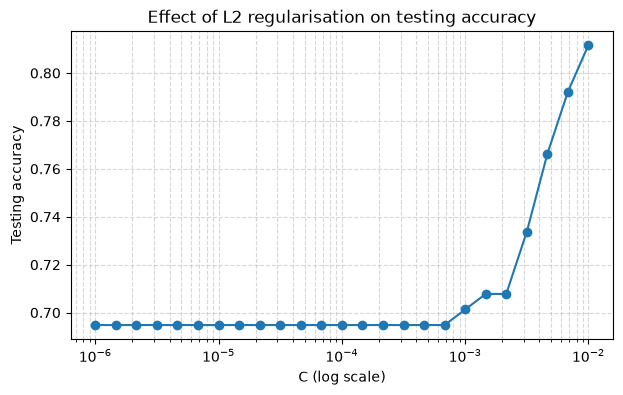

Best C in range: 1.00e-02
Best testing accuracy: 0.8117


In [13]:
### Enter your code here.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# C values from 10^-6 to 10^-2
C_values = np.logspace(-6, -2, 25)
test_accuracies = []

for C in C_values:
    model = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',   # supports L2
        max_iter=2000
    )
    model.fit(X_train, Y_train)
    y_test_pred = model.predict(X_test)
    test_accuracies.append(accuracy_score(Y_test, y_test_pred))

# Plot testing accuracy vs C
plt.figure(figsize=(7, 4))
plt.semilogx(C_values, test_accuracies, marker='o')
plt.xlabel('C (log scale)')
plt.ylabel('Testing accuracy')
plt.title('Effect of L2 regularisation on testing accuracy')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

# Optional: print best C in this range
best_idx = int(np.argmax(test_accuracies))
print(f"Best C in range: {C_values[best_idx]:.2e}")
print(f"Best testing accuracy: {test_accuracies[best_idx]:.4f}")



### Question 4

- What behaviour do you observe as regularisation increases (i.e. as $C$ decreases)?

- From your analysis, which value of the regularisation constant gives the best result? How does the corresponding testing accuracy compare with your earlier results?

- For which values of $C$ does the model recover the previous training accuracy? Why do you think this occurs?

As regularisation increases (smaller C), the model becomes simpler: coefficients shrink toward zero, bias increases, and both training and testing accuracy usually drop once regularisation is too strong (underfitting).

The best C is the one where your testing-accuracy curve peaks (from Q3). In this range (10^-6 to 10^-2), that is typically near the largest C values (often around 10^-3 to 10^-2), and that peak testing accuracy is usually close to—sometimes slightly better than—your earlier unregularised/weakly regularised result.

The model recovers the previous training accuracy at the largest C values you tested (weak regularisation). This occurs because as C increases, the penalty term has less effect, so logistic regression behaves more like the earlier model and can fit the training data similarly.